In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
import glob
import json
import numpy as np
import anndata as ad
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append("/code")
import bg_spatial_plots.plot_spatial_histograms as histplot

%matplotlib inline

# Plotting params

In [3]:
output_fig_dir = '/scratch/mat_paper_figures/for_YF_astro'
os.makedirs(output_fig_dir, exist_ok=True)

plt.rcParams.update({'font.size': 6})

# to get text as text and not paths in Illustrator
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

# this can mess with some plots, use cautiously
# plt.rcParams['figure.constrained_layout.use'] = True

# Load data

In [4]:
adata_rnaseq = ad.read_h5ad(
    '/data/snRNAseq_hmba_bg_human_astro_3subGroups/HMBA_human_Astro_3subGroups.h5ad',
)
adata_rnaseq

AnnData object with n_obs × n_vars = 134124 × 36601
    obs: 'Neighborhood', 'Class', 'Subclass', 'Group', 'Cluster', 'donor_id', 'anatomical_region', 'anatomical_region_merged', 'anatomical_region_ontology_term_id', 'self_reported_sex', 'self_reported_sex_ontology_term_id', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'disease', 'disease_ontology_term_id', 'suspension_type', 'is_primary_data', 'atac_confidently_mapped_read_pairs', 'atac_fraction_of_genome_in_peaks', 'atac_fraction_of_high_quality_fragments_in_cells', 'atac_fraction_of_high_quality_fragments_overlapping_tss', 'atac_fraction_of_high_quality_fragments_overlapping_peaks', 'atac_fraction_of_transposition_events_in_peaks_in_cells', 'atac_mean_raw_read_pairs_per_cell', 'atac_median_high_quality_fragments_per_cell', 'atac_non_nuclear_read_pairs', 'atac_number_of_peaks', 'atac_percent_duplicates', 'atac_q30_bases_in_barcode', 'atac_q30_bases_in_read_1', 'atac_q30_bases_in_read_2', 'atac_q30_bases_in_s

In [5]:
adata_rnaseq_self_map = ad.read_h5ad(
    '/data/snRNAseq_HMBA_Human_Astrocytes_MMC_self_mapping_with_spatial_gene_panel/HMBA_human_Astro_3subGroups_mmc_mapped-AIT_BG.h5ad',
)
adata_rnaseq_self_map

AnnData object with n_obs × n_vars = 134124 × 36601
    obs: 'Neighborhood', 'Class', 'Subclass', 'Group', 'Cluster', 'donor_id', 'anatomical_region', 'anatomical_region_merged', 'anatomical_region_ontology_term_id', 'self_reported_sex', 'self_reported_sex_ontology_term_id', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'disease', 'disease_ontology_term_id', 'suspension_type', 'is_primary_data', 'atac_confidently_mapped_read_pairs', 'atac_fraction_of_genome_in_peaks', 'atac_fraction_of_high_quality_fragments_in_cells', 'atac_fraction_of_high_quality_fragments_overlapping_tss', 'atac_fraction_of_high_quality_fragments_overlapping_peaks', 'atac_fraction_of_transposition_events_in_peaks_in_cells', 'atac_mean_raw_read_pairs_per_cell', 'atac_median_high_quality_fragments_per_cell', 'atac_non_nuclear_read_pairs', 'atac_number_of_peaks', 'atac_percent_duplicates', 'atac_q30_bases_in_barcode', 'atac_q30_bases_in_read_1', 'atac_q30_bases_in_read_2', 'atac_q30_bases_in_s

In [6]:
adata_spatial = ad.read_h5ad(
    '/data/cirro_files_hmba_human_20250922/hmba_release_format_human_cirro_h5ad_20250922.h5ad',
    backed='r'
)
adata_spatial

AnnData object with n_obs × n_vars = 6992128 × 314 backed at '/data/cirro_files_hmba_human_20250922/hmba_release_format_human_cirro_h5ad_20250922.h5ad'
    obs: 'x', 'y', 'brain_section_label', 'brain_section_barcode', 'slab', 'block', 'set', 'z_order', 'total_counts', 'total_counts_genes', 'n_genes_by_counts', 'total_counts_Blank', 'pct_counts_Blank', 'genes_filter', 'counts_filter', 'blanks_filter', 'qc_pass', 'doublets_filter', 'qc_pass_and_singlet', 'doublet_singlet_score_diff', 'doublet_diff_threshold', 'hierarchy_consistent', 'Neighborhood', 'Neighborhood_bootstrapping_probability', 'Neighborhood_correlation_coefficient', 'Class', 'Class_bootstrapping_probability', 'Class_correlation_coefficient', 'Subclass', 'Subclass_bootstrapping_probability', 'Subclass_correlation_coefficient', 'Group', 'Group_bootstrapping_probability', 'Group_correlation_coefficient', 'cluster_id', 'cluster_id_bootstrapping_probability', 'cluster_id_correlation_coefficient', 'Neighborhood_entropy', 'Class_e

# Self-mapping results

In [7]:
# convert all the mapped cluster names from format "Human-7" to "h-7"
adata_rnaseq_self_map.obs['CDM_cluster_id_name_h'] = adata_rnaseq_self_map.obs['CDM_cluster_id_name'].str.replace('Human-', 'h-')

# need to transfer the subGroup labels for the self-mapping cluster results
# make a mapping for each unique cluster label to the subGroup label, confirming all cells in a cluster share the same subGroup label
cluster_to_subgroup = {}
for cluster in adata_rnaseq_self_map.obs['cluster'].unique():
    cluster_cells = adata_rnaseq_self_map.obs[adata_rnaseq_self_map.obs['cluster'] == cluster]
    unique_subgroups = cluster_cells['subGroup'].unique()
    assert len(unique_subgroups) == 1, f"Cluster {cluster} has multiple subGroups: {unique_subgroups}"
    cluster_to_subgroup[cluster] = unique_subgroups[0]

for cluster in adata_rnaseq_self_map.obs['CDM_cluster_id_name_h'].unique():
    if cluster not in cluster_to_subgroup:
        cluster_to_subgroup[cluster] = 'Non-Astrocyte'

# add the subGroup labels to the self-mapping adata
adata_rnaseq_self_map.obs['CDM_subGroup_name'] = adata_rnaseq_self_map.obs['CDM_cluster_id_name_h'].map(cluster_to_subgroup)

# update categories
adata_rnaseq_self_map.obs['CDM_subGroup_name'] = adata_rnaseq_self_map.obs['CDM_subGroup_name'].astype('category')
adata_rnaseq_self_map.obs['subGroup'] = adata_rnaseq_self_map.obs['subGroup'].astype('category')

# set subGroup order
all_subGroups_ordered = ['GM STR', 'GM exSTR', 'WM', 'Non-Astrocyte']
adata_rnaseq_self_map.obs['CDM_subGroup_name'] = adata_rnaseq_self_map.obs['CDM_subGroup_name'].cat.set_categories(all_subGroups_ordered, ordered=True)
adata_rnaseq_self_map.obs['subGroup'] = adata_rnaseq_self_map.obs['subGroup'].cat.set_categories(all_subGroups_ordered, ordered=True)

In [8]:
def sort_cluster_labels(labels):
    '''Sort cluster labels in the format "Human-7" by the numeric part of the label.'''
    def sort_key(label):
        parts = label.split('-') # sort by the cluster id # only
        num_part = parts[-1] if parts[-1].isdigit() else ''
        return num_part.zfill(5) if num_part else label  # pad with leading zeros for correct lexicographic ordering
    return sorted(labels, key=sort_key)
    
group_to_cluster_list = {}
for cluster, subgroup in cluster_to_subgroup.items():
    if subgroup not in group_to_cluster_list:
        group_to_cluster_list[subgroup] = []
    group_to_cluster_list[subgroup].append(cluster)

for group, cluster_list in group_to_cluster_list.items():
    # sort the cluster list for each group
    sorted_list = sort_cluster_labels(cluster_list)
    # display(sorted_list)
    group_to_cluster_list[group] = sorted_list

display(group_to_cluster_list)

{'GM STR': ['h-7', 'h-14', 'h-31'],
 'GM exSTR': ['h-145',
  'h-146',
  'h-149',
  'h-150',
  'h-152',
  'h-159',
  'h-160',
  'h-450',
  'h-452'],
 'WM': ['h-28', 'h-227', 'h-230', 'h-231', 'h-472', 'h-479', 'h-485'],
 'Non-Astrocyte': ['h-1',
  'h-13',
  'h-15',
  'h-20',
  'h-49',
  'h-50',
  'h-70',
  'h-84',
  'h-88',
  'h-103',
  'h-112',
  'h-113',
  'h-114',
  'h-116',
  'h-119',
  'h-121',
  'h-125',
  'h-133',
  'h-138',
  'h-140',
  'h-142',
  'h-143',
  'h-169',
  'h-180',
  'h-188',
  'h-210',
  'h-211',
  'h-212',
  'h-213',
  'h-214',
  'h-217',
  'h-218',
  'h-232',
  'h-245',
  'h-256',
  'h-267',
  'h-283',
  'h-293',
  'h-301',
  'h-309',
  'h-312',
  'h-315',
  'h-316',
  'h-337',
  'h-360',
  'h-379',
  'h-385',
  'h-392',
  'h-407',
  'h-420',
  'h-474',
  'h-475',
  'h-476',
  'h-492',
  'h-494',
  'h-500',
  'h-509',
  'h-516',
  'h-524',
  'h-536',
  'h-564']}

In [9]:
# set the cat order for both columns based on the joined sorted cluster lists
cat_order = [sublist for group in group_to_cluster_list.values() for sublist in group]

adata_rnaseq_self_map.obs['CDM_cluster_id_name_h'] = pd.Categorical(
    adata_rnaseq_self_map.obs['CDM_cluster_id_name_h'],
    categories=cat_order,
    ordered=True
)
adata_rnaseq_self_map.obs['cluster'] = pd.Categorical(
    adata_rnaseq_self_map.obs['cluster'],
    categories=cat_order,
    ordered=True
)

In [10]:
def plot_confusion_matrix(
    obs_df, 
    annot_col, 
    mapped_col, 
    cmap='inferno',
    annot_values_on_heatmap=True,
    fig_size=(4,4),
    vlims=None,
):
    """
    Plot raw and normalized confusion matrices for two categorical columns.
    
    Parameters
    ----------
    obs_df : pd.DataFrame
        The .obs dataframe containing the columns to compare.
    annot_col : str
        Column name to use as true labels (plotted on columns).
    mapped_col : str
        Column name to use as mapped labels (plotted on rows).
    cmap : str, optional
        Colormap for the heatmaps. Default is 'magma_r'.
    """
    import seaborn as sns
    from sklearn.metrics import confusion_matrix

    true_labels = obs_df[annot_col]
    mapped_labels = obs_df[mapped_col]

    # all_labels = sorted(set(true_labels.unique()) | set(mapped_labels.unique()))
    all_labels = list(pd.Categorical(true_labels).categories)

    cm = confusion_matrix(true_labels, mapped_labels, labels=all_labels)

    cm_df = pd.DataFrame(
        cm.T,
        index=all_labels,
        columns=all_labels
    )
    cm_df.index.name = f'Mapped ({mapped_col})'
    cm_df.columns.name = f'Annotated ({annot_col})'

    # cm_norm = cm_df.div(cm_df.sum(axis=0), axis=1)
    cm_norm = cm_df.div(cm_df.sum(axis=0), axis=1).fillna(0)

    n_labels = len(all_labels)

    fig, ax = plt.subplots(1, 1, figsize=fig_size)

    # sns.heatmap(
    #     cm_df,
    #     ax=axes[0],
    #     cmap=cmap,
    #     annot=True,
    #     fmt='d',
    #     square=True,
    #     cbar_kws={'label': 'Cell Count'},
    #     xticklabels=True,
    #     yticklabels=True
    # )
    # axes[0].set_title(f'Confusion Matrix: {annot_col} vs {mapped_col}\n(raw counts)')
    # axes[0].tick_params(axis='x', rotation=90)
    # axes[0].tick_params(axis='y', rotation=0)

    if vlims is not None:
        vmin, vmax = vlims
    else:
        vmin, vmax = None, None

    # Create a custom annotation matrix for non-zero values
    if annot_values_on_heatmap:
        annot_matrix = cm_norm.apply(lambda row: row.map(lambda x: f"{x:.2f}" if x >= 0.005 else ""))   
        fmt = ''  # No need for additional formatting since values are already formatted in the matrix
    else:
        annot_matrix = None
        fmt = '.2f'  # Default formatting for any annotations if they were to be added

    sns.heatmap(
        cm_norm,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        annot=annot_matrix,
        fmt=fmt,
        square=True,
        cbar_kws={'label': 'Fraction Mapped'},
        xticklabels=True,
        yticklabels=True
    )
    ax.set_title(f'Confusion Matrix: {annot_col} vs {mapped_col}\n(normalized by annotated label)')
    ax.tick_params(axis='x', rotation=90)
    ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.show()

    return fig

## Subclass level mapping

"99.9% of snRNA-seq cells annotated as in the Astrocyte Subclass accurately self-map to the Astrocyte Subclass when using only the 299 genes from the MERSCOPE spatial transcriptomics panel"

In [11]:
adata_rnaseq_self_map.obs['CDM_Subclass_name'].value_counts(normalize=True)

CDM_Subclass_name
Astrocyte              0.998897
Ependymal              0.000231
STR Hybrid MSN         0.000164
M Dopa                 0.000119
Oligodendrocyte        0.000104
STR RSPO2 GABA         0.000067
CN VIP GABA            0.000060
STR D2 MSN             0.000060
CN MEIS2 GABA          0.000045
CN LHX8 GABA           0.000045
STR D1 MSN             0.000037
OPC                    0.000037
Adjacent               0.000030
F M Glut               0.000022
CN Cholinergic GABA    0.000015
CN LAMP5-LHX6 GABA     0.000015
SN PAX7 GABA           0.000015
COP                    0.000007
F M GATA3 GABA         0.000007
F GABA                 0.000007
Pericyte               0.000007
STR SST-CHODL GABA     0.000007
Name: proportion, dtype: float64

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


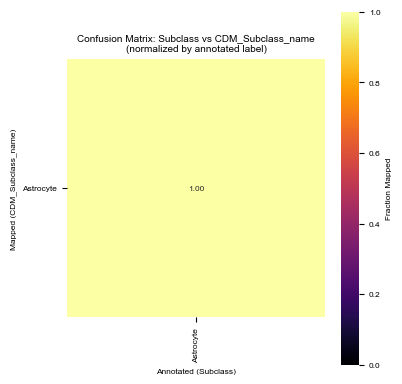

In [12]:
# Subclass confusion matrix
cm_subclass_all_cells = plot_confusion_matrix(
    obs_df=adata_rnaseq_self_map.obs,
    annot_col='Subclass',
    mapped_col='CDM_Subclass_name',
    cmap='inferno',
    annot_values_on_heatmap=True,
    fig_size=(4,4),
    vlims=(0,1)
)

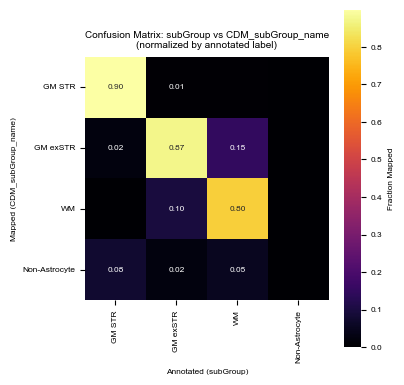

In [13]:
# Astrocyte subGroup confusion matrix
cm_subgroups_with_nonastro = plot_confusion_matrix(
    adata_rnaseq_self_map.obs, 
    annot_col='subGroup',  
    mapped_col='CDM_subGroup_name', 
    cmap='inferno', 
    annot_values_on_heatmap=True,
    fig_size=(4,4),
)

In [14]:
# remove any cells that mapped to "Non-Astrocyte"
adata_rnaseq_self_map_astro = adata_rnaseq_self_map[adata_rnaseq_self_map.obs['CDM_subGroup_name'] != 'Non-Astrocyte'].copy()

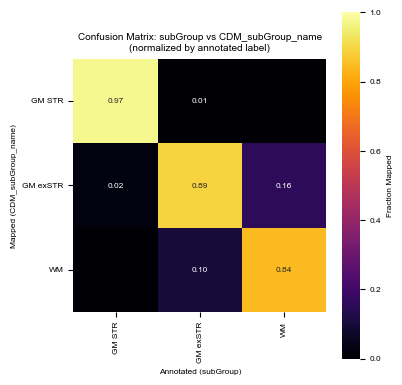

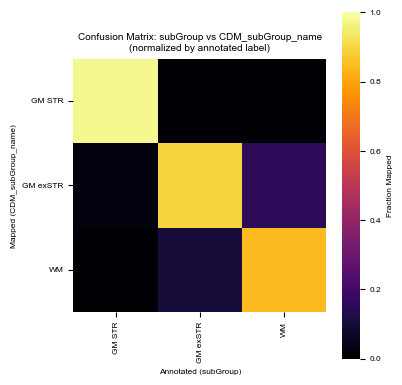

In [15]:
# plot the confusion matrix again after removing non-astrocyte mapped cells
cm_subgroups_astro_annot = plot_confusion_matrix(
    adata_rnaseq_self_map_astro.obs, 
    annot_col='subGroup',  
    mapped_col='CDM_subGroup_name', 
    cmap='inferno', 
    annot_values_on_heatmap=True, 
    vlims=(0,1),
    fig_size=(4,4),
)
cm_subgroups_astro_annot.savefig(f'{output_fig_dir}/rnaseq_confusion_matrix_subgroups_astro_annot.png', bbox_inches='tight', dpi=300)
cm_subgroups_astro_annot.savefig(f'{output_fig_dir}/rnaseq_confusion_matrix_subgroups_astro_annot.pdf', bbox_inches='tight')

cm_subgroups_astro = plot_confusion_matrix(
    adata_rnaseq_self_map_astro.obs, 
    annot_col='subGroup',  
    mapped_col='CDM_subGroup_name', 
    cmap='inferno', 
    annot_values_on_heatmap=False, 
    vlims=(0,1),
    fig_size=(4,4),
)
cm_subgroups_astro.savefig(f'{output_fig_dir}/rnaseq_confusion_matrix_subgroups_astro.png', bbox_inches='tight', dpi=300)
cm_subgroups_astro.savefig(f'{output_fig_dir}/rnaseq_confusion_matrix_subgroups_astro.pdf', bbox_inches='tight')

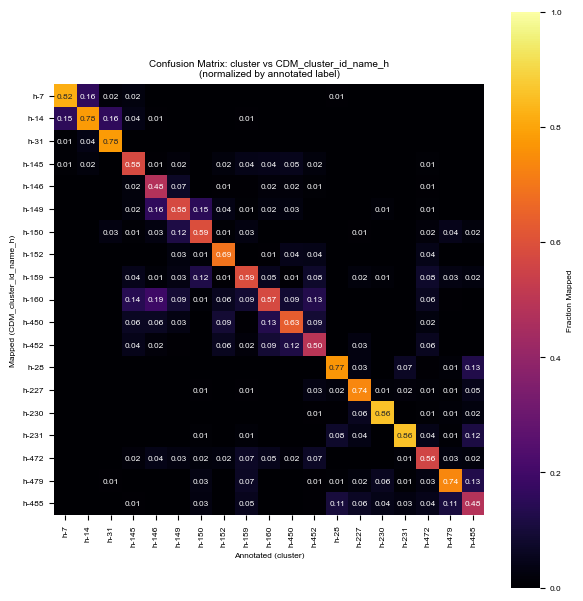

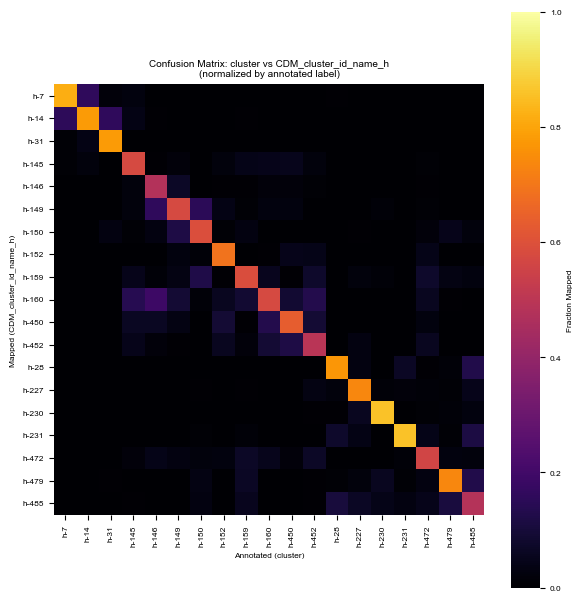

In [16]:
# Astrocyte cluster confusion matrix
cm_clusters_astro_annot = plot_confusion_matrix(
    adata_rnaseq_self_map_astro.obs, 
    annot_col='cluster', 
    mapped_col='CDM_cluster_id_name_h', 
    cmap='inferno', 
    annot_values_on_heatmap=True, 
    vlims=(0,1),
    fig_size=(6,6),
)
cm_clusters_astro_annot.savefig(f'{output_fig_dir}/rnaseq_confusion_matrix_clusters_astro_annot.pdf', bbox_inches='tight')


# no annot labels
cm_clusters_astro = plot_confusion_matrix(
    adata_rnaseq_self_map_astro.obs, 
    annot_col='cluster', 
    mapped_col='CDM_cluster_id_name_h', 
    cmap='inferno', 
    annot_values_on_heatmap=False, 
    vlims=(0,1),
    fig_size=(6,6),
)
cm_clusters_astro.savefig(f'{output_fig_dir}/rnaseq_confusion_matrix_clusters_astro.pdf', bbox_inches='tight')

In [17]:
adata_rnaseq_self_map.obs.loc[:, ['CDM_Neighborhood_label',
 'CDM_Neighborhood_name',
 'CDM_Neighborhood_bootstrapping_probability',
 'CDM_Neighborhood_aggregate_probability',
 'CDM_Neighborhood_avg_correlation',
 'CDM_Neighborhood_directly_assigned',
 'CDM_Class_label',
 'CDM_Class_name',
 'CDM_Class_bootstrapping_probability',
 'CDM_Class_aggregate_probability',
 'CDM_Class_avg_correlation',
 'CDM_Class_directly_assigned',
 'CDM_Subclass_label',
 'CDM_Subclass_name',
 'CDM_Subclass_bootstrapping_probability',
 'CDM_Subclass_aggregate_probability',
 'CDM_Subclass_avg_correlation',
 'CDM_Subclass_directly_assigned',
 'CDM_Group_label',
 'CDM_Group_name',
 'CDM_Group_bootstrapping_probability',
 'CDM_Group_aggregate_probability',
 'CDM_Group_avg_correlation',
 'CDM_Group_directly_assigned',
 'CDM_cluster_id_label',
 'CDM_cluster_id_name',
 'CDM_cluster_id_alias',
 'CDM_cluster_id_bootstrapping_probability',
 'CDM_cluster_id_aggregate_probability',
 'CDM_cluster_id_avg_correlation',
 'CDM_cluster_id_directly_assigned',
 'CDM_cluster_id_runner_up_assignment_0',
 'CDM_cluster_id_runner_up_correlation_0',
 'CDM_cluster_id_runner_up_probability_0',
 'CDM_Subclass_runner_up_assignment_0',
 'CDM_Subclass_runner_up_correlation_0',
 'CDM_Subclass_runner_up_probability_0',
 'CDM_Group_runner_up_assignment_0',
 'CDM_Group_runner_up_correlation_0',
 'CDM_Group_runner_up_probability_0',]]

,CDM_Neighborhood_label,CDM_Neighborhood_name,CDM_Neighborhood_bootstrapping_probability,CDM_Neighborhood_aggregate_probability,CDM_Neighborhood_avg_correlation,CDM_Neighborhood_directly_assigned,CDM_Class_label,CDM_Class_name,CDM_Class_bootstrapping_probability,CDM_Class_aggregate_probability,...,CDM_cluster_id_directly_assigned,CDM_cluster_id_runner_up_assignment_0,CDM_cluster_id_runner_up_correlation_0,CDM_cluster_id_runner_up_probability_0,CDM_Subclass_runner_up_assignment_0,CDM_Subclass_runner_up_correlation_0,CDM_Subclass_runner_up_probability_0,CDM_Group_runner_up_assignment_0,CDM_Group_runner_up_correlation_0,CDM_Group_runner_up_probability_0
AAACAGCCATTGTGGC-2362_A05,Nonneuron,Nonneuron,1.0,1.0,0.781906,False,Astro-Epen,Astro-Epen,1.0,1.0,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAACATGCAGTAGGAT-2362_A05,Nonneuron,Nonneuron,1.0,1.0,0.750268,False,Astro-Epen,Astro-Epen,1.0,1.0,...,True,Human-159,0.751130,0.31,NaN,NaN,NaN,NaN,NaN,NaN
AAACCGCGTTGACTTC-2362_A05,Nonneuron,Nonneuron,1.0,1.0,0.802318,False,Astro-Epen,Astro-Epen,1.0,1.0,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAAGCCGCACCTAATG-2362_A05,Nonneuron,Nonneuron,1.0,1.0,0.724517,False,Astro-Epen,Astro-Epen,1.0,1.0,...,True,Human-232,0.722643,0.07,Astrocyte,0.723104,0.08,Astrocyte,0.723104,0.08
AAAGCGGGTCATCATC-2362_A05,Nonneuron,Nonneuron,1.0,1.0,0.791270,False,Astro-Epen,Astro-Epen,1.0,1.0,...,True,Human-159,0.791943,0.08,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTAGCTTCCTACCTA-2016_B03,Nonneuron,Nonneuron,1.0,1.0,0.808086,False,Astro-Epen,Astro-Epen,1.0,1.0,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TTTAGGATCACTAGGT-2016_B03,Nonneuron,Nonneuron,1.0,1.0,0.756349,False,Astro-Epen,Astro-Epen,1.0,1.0,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TTTATGGAGTTGTCCC-2016_B03,Nonneuron,Nonneuron,1.0,1.0,0.795245,False,Astro-Epen,Astro-Epen,1.0,1.0,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TTTGACCGTGCTTTAC-2016_B03,Nonneuron,Nonneuron,1.0,1.0,0.823184,False,Astro-Epen,Astro-Epen,1.0,1.0,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
adata_rnaseq_self_map.obs[[
    'Neighborhood',
    'Class',
    'Subclass',
    'Group',
    'Cluster',
    'CDM_Neighborhood_name',
    'CDM_Neighborhood_bootstrapping_probability',
    'CDM_Neighborhood_aggregate_probability',
    'CDM_Neighborhood_avg_correlation',
    'CDM_Class_name',
    'CDM_Class_bootstrapping_probability',
    'CDM_Class_aggregate_probability',
    'CDM_Class_avg_correlation',
    'CDM_Subclass_name',
    'CDM_Subclass_bootstrapping_probability',
    'CDM_Subclass_aggregate_probability',
    'CDM_Subclass_avg_correlation',
    'CDM_Group_name',
    'CDM_Group_bootstrapping_probability',
    'CDM_Group_aggregate_probability',
    'CDM_Group_avg_correlation',
    'CDM_cluster_id_name',
    'CDM_cluster_id_bootstrapping_probability',
    'CDM_cluster_id_aggregate_probability',
]]

,Neighborhood,Class,Subclass,Group,Cluster,CDM_Neighborhood_name,CDM_Neighborhood_bootstrapping_probability,CDM_Neighborhood_aggregate_probability,CDM_Neighborhood_avg_correlation,CDM_Class_name,...,CDM_Subclass_bootstrapping_probability,CDM_Subclass_aggregate_probability,CDM_Subclass_avg_correlation,CDM_Group_name,CDM_Group_bootstrapping_probability,CDM_Group_aggregate_probability,CDM_Group_avg_correlation,CDM_cluster_id_name,CDM_cluster_id_bootstrapping_probability,CDM_cluster_id_aggregate_probability
AAACAGCCATTGTGGC-2362_A05,Nonneuron,Astro-Epen,Astrocyte,Astrocyte,Human-14,Nonneuron,1.0,1.0,0.781906,Astro-Epen,...,1.00,1.00,0.781906,Astrocyte,1.00,1.00,0.781906,Human-7,1.00,1.00
AAACATGCAGTAGGAT-2362_A05,Nonneuron,Astro-Epen,Astrocyte,Astrocyte,Human-159,Nonneuron,1.0,1.0,0.750268,Astro-Epen,...,1.00,1.00,0.750268,Astrocyte,1.00,1.00,0.750268,Human-145,0.69,0.69
AAACCGCGTTGACTTC-2362_A05,Nonneuron,Astro-Epen,Astrocyte,Astrocyte,Human-14,Nonneuron,1.0,1.0,0.802318,Astro-Epen,...,1.00,1.00,0.802318,Astrocyte,1.00,1.00,0.802318,Human-14,1.00,1.00
AAAGCCGCACCTAATG-2362_A05,Nonneuron,Astro-Epen,Astrocyte,Astrocyte,Human-28,Nonneuron,1.0,1.0,0.724517,Astro-Epen,...,0.92,0.92,0.724640,Ependymal,0.92,0.92,0.724640,Human-113,0.92,0.92
AAAGCGGGTCATCATC-2362_A05,Nonneuron,Astro-Epen,Astrocyte,Astrocyte,Human-160,Nonneuron,1.0,1.0,0.791270,Astro-Epen,...,1.00,1.00,0.791270,Astrocyte,1.00,1.00,0.791270,Human-160,0.92,0.92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTAGCTTCCTACCTA-2016_B03,Nonneuron,Astro-Epen,Astrocyte,Astrocyte,Human-14,Nonneuron,1.0,1.0,0.808086,Astro-Epen,...,1.00,1.00,0.808086,Astrocyte,1.00,1.00,0.808086,Human-14,1.00,1.00
TTTAGGATCACTAGGT-2016_B03,Nonneuron,Astro-Epen,Astrocyte,Astrocyte,Human-14,Nonneuron,1.0,1.0,0.756349,Astro-Epen,...,1.00,1.00,0.756349,Astrocyte,1.00,1.00,0.756349,Human-14,1.00,1.00
TTTATGGAGTTGTCCC-2016_B03,Nonneuron,Astro-Epen,Astrocyte,Astrocyte,Human-14,Nonneuron,1.0,1.0,0.795245,Astro-Epen,...,1.00,1.00,0.795245,Astrocyte,1.00,1.00,0.795245,Human-14,1.00,1.00
TTTGACCGTGCTTTAC-2016_B03,Nonneuron,Astro-Epen,Astrocyte,Astrocyte,Human-14,Nonneuron,1.0,1.0,0.823184,Astro-Epen,...,1.00,1.00,0.823184,Astrocyte,1.00,1.00,0.823184,Human-14,1.00,1.00


In [19]:
adata_rnaseq_self_map.obs['CDM_Group_name'].value_counts(normalize=True)

CDM_Group_name
Astrocyte                         0.992268
ImAstro                           0.006628
Ependymal                         0.000231
STRv D1 NUDAP MSN                 0.000157
SN SOX6 Dopa                      0.000119
Oligo OPALIN                      0.000075
STR LYPD6-RSPO2 GABA              0.000067
VIP GABA                          0.000060
GPe MEIS2-SOX6 GABA               0.000045
OPC                               0.000037
STRd D2 Matrix MSN                0.000030
Adjacent                          0.000030
ImOligo                           0.000022
GPe SOX6-CTXND1 GABA              0.000022
GPe-NDB-SI LHX6-LHX8-GBX1 GABA    0.000022
VTR-HTH Glut                      0.000022
STRv D1 MSN                       0.000022
STRd D2 Striosome MSN             0.000015
LAMP5-LHX6 GABA                   0.000015
GPin-BF Cholinergic GABA          0.000015
STRv D2 MSN                       0.000015
STRd D1 Striosome MSN             0.000015
AMY-SLEA-BNST GABA                0.000

In [20]:
adata_rnaseq_self_map.obs['CDM_Group_name'].value_counts(normalize=False)

CDM_Group_name
Astrocyte                         133087
ImAstro                              889
Ependymal                             31
STRv D1 NUDAP MSN                     21
SN SOX6 Dopa                          16
Oligo OPALIN                          10
STR LYPD6-RSPO2 GABA                   9
VIP GABA                               8
GPe MEIS2-SOX6 GABA                    6
OPC                                    5
STRd D2 Matrix MSN                     4
Adjacent                               4
ImOligo                                3
GPe SOX6-CTXND1 GABA                   3
GPe-NDB-SI LHX6-LHX8-GBX1 GABA         3
VTR-HTH Glut                           3
STRv D1 MSN                            3
STRd D2 Striosome MSN                  2
LAMP5-LHX6 GABA                        2
GPin-BF Cholinergic GABA               2
STRv D2 MSN                            2
STRd D1 Striosome MSN                  2
AMY-SLEA-BNST GABA                     1
Oligo PLEKHG1                          1
C

In [21]:
# value counts for Astrocyte+ImAstro vs rest
display(adata_rnaseq_self_map.obs['CDM_Group_name'].apply(lambda x: 'Astrocyte+ImAstro' if x in ['Astrocyte', 'ImAstro'] else 'Other').value_counts(normalize=True))
display(adata_rnaseq_self_map.obs['CDM_Group_name'].apply(lambda x: 'Astrocyte+ImAstro' if x in ['Astrocyte', 'ImAstro'] else 'Other').value_counts(normalize=False))

CDM_Group_name
Astrocyte+ImAstro    0.998897
Other                0.001103
Name: proportion, dtype: float64

CDM_Group_name
Astrocyte+ImAstro    133976
Other                   148
Name: count, dtype: int64

In [22]:
display(adata_rnaseq_self_map.obs['CDM_Group_name'].apply(lambda x: 'Astrocyte+ImAstro' if x in ['Astrocyte'] else 'Other').value_counts(normalize=True))
display(adata_rnaseq_self_map.obs['CDM_Group_name'].apply(lambda x: 'Astrocyte+ImAstro' if x in ['Astrocyte'] else 'Other').value_counts(normalize=False))

CDM_Group_name
Astrocyte+ImAstro    0.992268
Other                0.007732
Name: proportion, dtype: float64

CDM_Group_name
Astrocyte+ImAstro    133087
Other                  1037
Name: count, dtype: int64